In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [2]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [3]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe() #how can be bloodpressure and other can  be 0?
              #can insulin be 0?, if not then its also 0 at 25%
              #can insulin be 846?

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:
cols_with_invalid_zero = [ 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI']

for col in cols_with_invalid_zero:
    zero_counts = (df[col]==0).sum()
    print(f"{col} : {zero_counts} and {zero_counts/len(df)*100:.1f}")

Glucose : 5 and 0.7
BloodPressure : 35 and 4.6
SkinThickness : 227 and 29.6
Insulin : 374 and 48.7
BMI : 11 and 1.4


In [8]:
df.columns


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [9]:
for col in cols_with_invalid_zero:
    print(col, (df[col]==0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [10]:
for col in [ 'Glucose', 'BloodPressure','BMI']:
    median = df[df[col]!= 0][col].median()
    df[col] = df[col].replace(0,median)

In [11]:
for col in [ 'SkinThickness', 'Insulin']:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))

In [12]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.0,169.5,33.6,0.627,50,1
1,1,85,66,29.0,102.5,26.6,0.351,31,0
2,8,183,64,32.0,169.5,23.3,0.672,32,1
3,1,89,66,23.0,94.0,28.1,0.167,21,0
4,0,137,40,35.0,168.0,43.1,2.288,33,1


<Axes: xlabel='Pregnancies', ylabel='Outcome'>

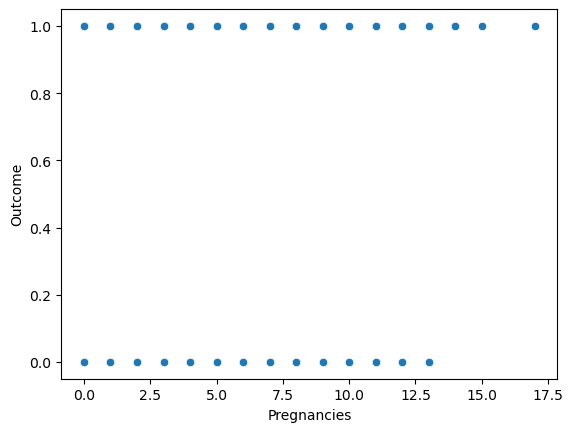

In [15]:
sns.scatterplot(df, x='Pregnancies', y='Outcome') #i think pregnancies doesnt matter

<Axes: xlabel='Glucose', ylabel='Outcome'>

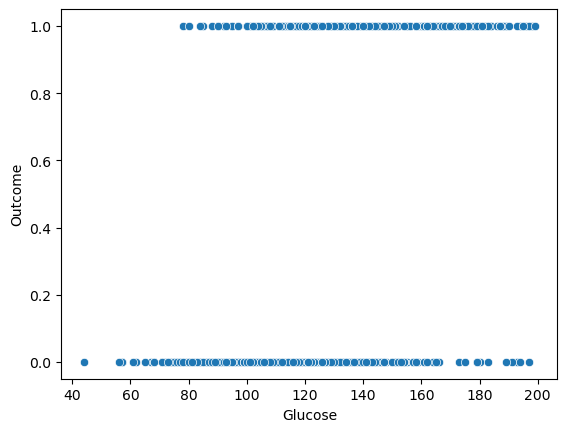

In [16]:
sns.scatterplot(df, x='Glucose',y='Outcome')

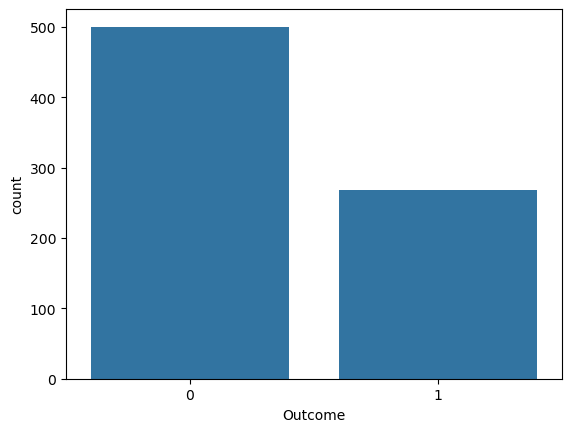

In [17]:
sns.countplot(x="Outcome", data=df)
plt.show()

<Axes: >

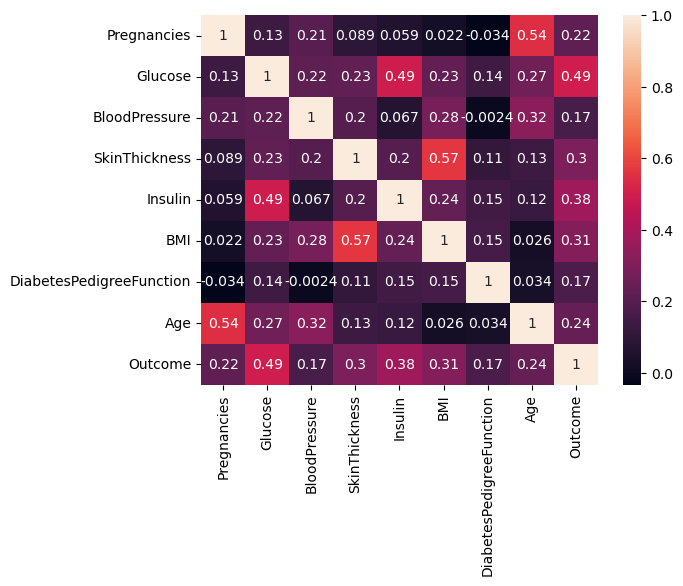

In [19]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [20]:
X = df.drop(columns='Outcome')
y= df['Outcome']

In [21]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [25]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
from sklearn.neighbors import KNeighborsClassifier


In [27]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [28]:
y_pred_knn = model_knn.predict(X_test_scaled)
y_pred_knn

array([1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1])

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_score(y_test, y_pred_knn)
confusion_matrix(y_test, y_pred_knn)
classification_report(y_test, y_pred_knn)

'              precision    recall  f1-score   support\n\n           0       0.87      0.82      0.84        99\n           1       0.70      0.78      0.74        55\n\n    accuracy                           0.81       154\n   macro avg       0.79      0.80      0.79       154\nweighted avg       0.81      0.81      0.81       154\n'

In [33]:
import joblib

joblib.dump(model_knn, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']

In [34]:

confusion_matrix(y_test, y_pred_knn)

array([[81, 18],
       [12, 43]])

In [35]:
accuracy_score(y_test, y_pred_knn)

0.8051948051948052

<Axes: >

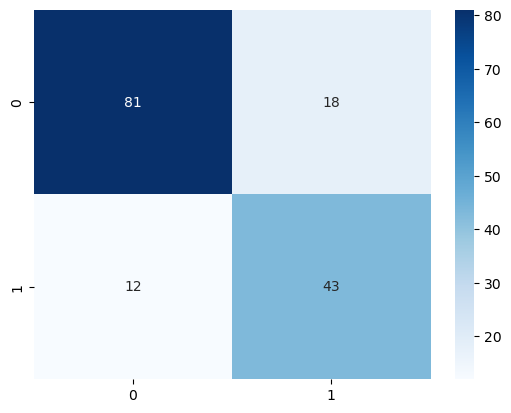

In [37]:
cm = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm,
            annot=True,
            
            cmap="Blues")




In [38]:
new_patient = [[2,120,70,20,80,25.3,0.5,32]]

new_patient = scaler.transform(new_patient)

prediction = model_knn.predict(new_patient)

print(prediction)

[0]


E:\knee bomba\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
